# Titanic Exploratory Data Analysis (EDA)

This project explores the Titanic dataset to identify factors that influenced passenger survival. The analysis covers data cleaning, missing value handling, visualization, feature engineering, and correlation analysis.

## Upload dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


#1. Import libraries and load the dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Dataset overview

In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 3. Statistical summary

In [8]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 4. Duplicate check

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 5. Missing value handling

Strategy used:
- Fill `Age` with median
- Fill `Embarked` with mode
- Drop `Cabin` from the cleaned dataset used for correlation analysis


In [12]:
# create clean copy
df_clean = df.copy()

#handling missing values
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

#drop cabin
df_clean = df_clean.drop(columns=["Cabin"])

#cleaning missing values again
print(df_clean.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 6. Feature engineering

In [13]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


## 7. Univariate analysis

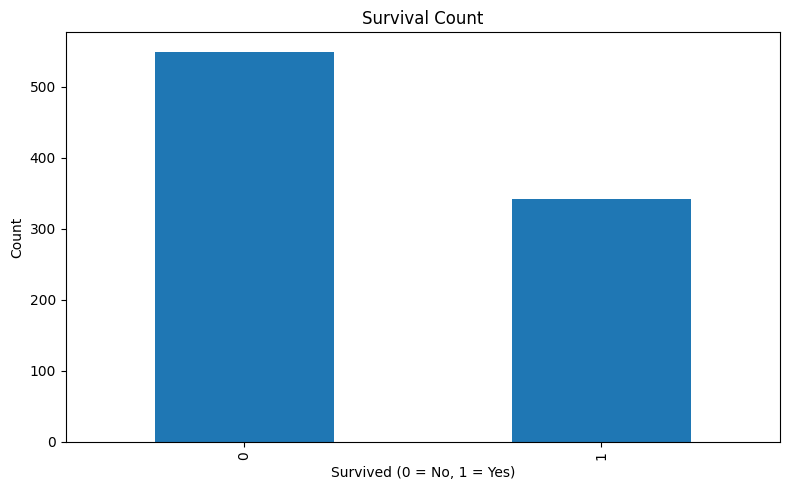

In [14]:
#Survival count
df["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

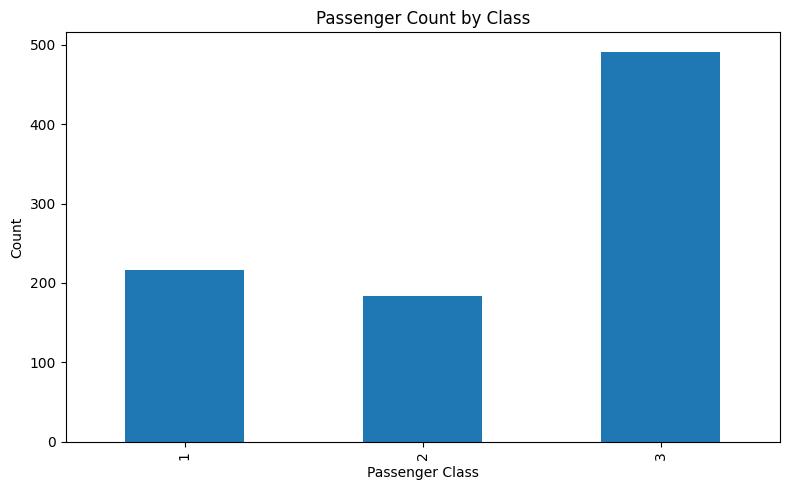

In [15]:
#passenger class chart
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Count by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

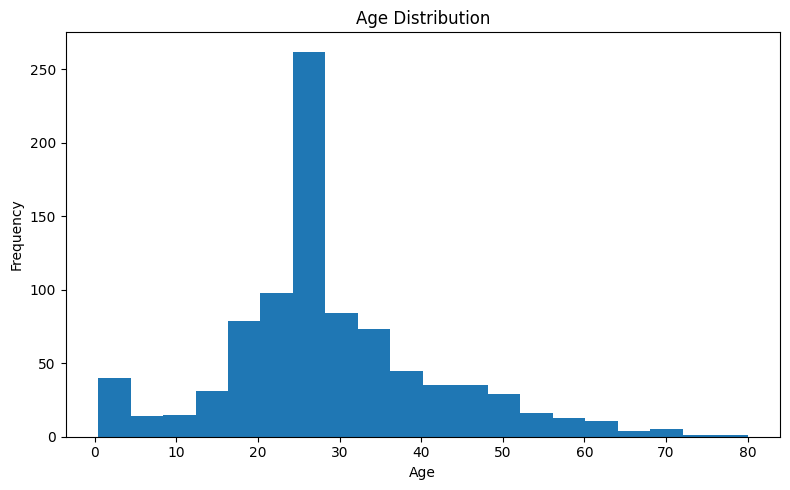

In [16]:
#age distribution chart
df_clean["Age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 8. Bivariate analysis

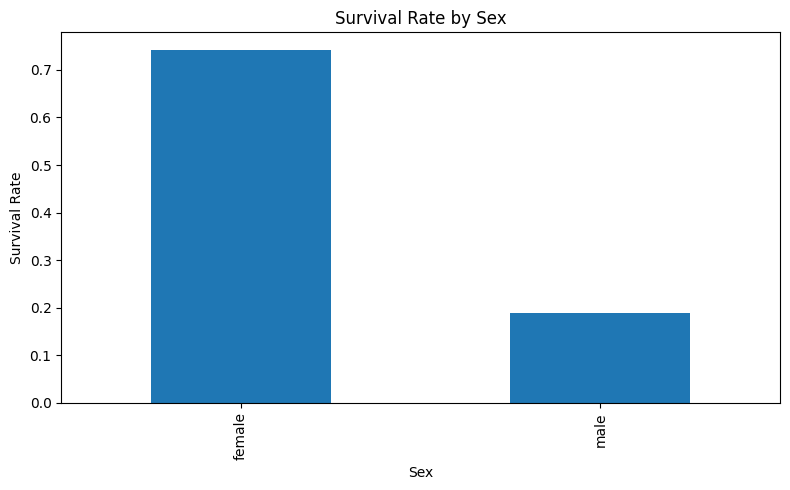

,Survived
Sex,
female,0.742038
male,0.188908


In [17]:
#survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
survival_by_sex.plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

survival_by_sex

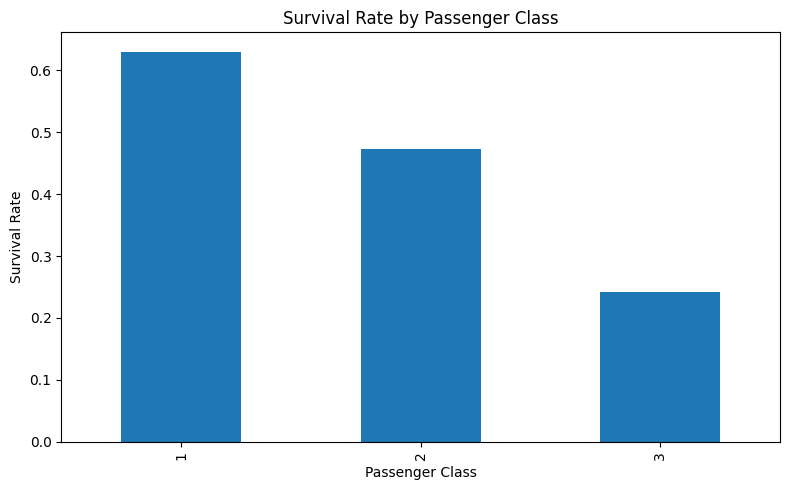

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [18]:
#survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean().sort_index()
survival_by_class.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

survival_by_class

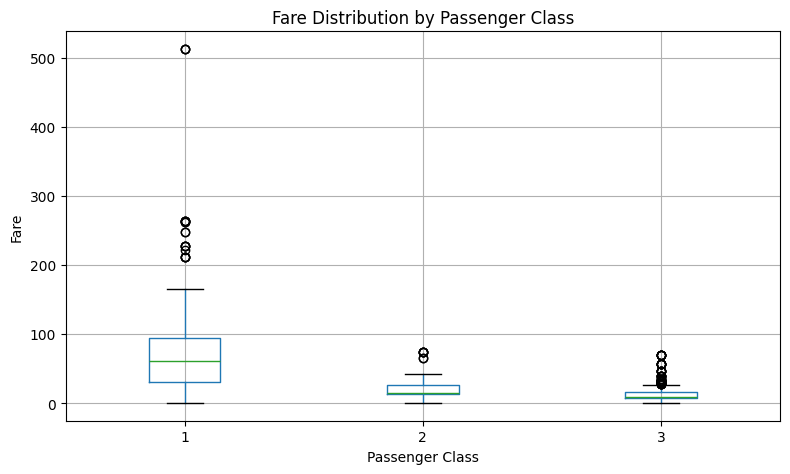

In [19]:
#Fare by class
df.boxplot(column="Fare", by="Pclass")
plt.title("Fare Distribution by Passenger Class")
plt.suptitle("")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

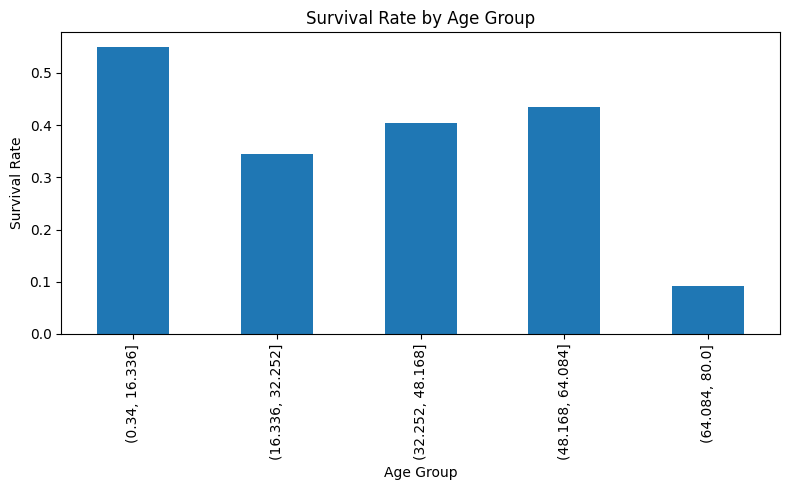

,Survived
Age,
"(0.34, 16.336]",0.550000
"(16.336, 32.252]",0.344168
"(32.252, 48.168]",0.404255
"(48.168, 64.084]",0.434783
"(64.084, 80.0]",0.090909


In [20]:
#survival by age group
age_group_survival = df_clean.groupby(pd.cut(df_clean["Age"], bins=5), observed=False)["Survived"].mean()
age_group_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

age_group_survival

Prepare for correlation analysis

In [24]:
df_encoded = df_clean.copy()

## 9. Encoding for correlation analysis

In [25]:
#Drop text-heavy columns for correlation
df_encoded = df_encoded.drop(columns=["PassengerId", "Name", "Ticket"])

# df_encoded = df_clean.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"]).copy()
#Encode sex
df_encoded["Sex"] = df_encoded["Sex"].map({"male": 0, "female": 1})
#Encode embarked
df_encoded = pd.get_dummies(df_encoded, columns=["Embarked"], drop_first=True)
df_encoded.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,False,True
1,1,1,1,38.0,1,0,71.2833,2,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


## 10. Correlation analysis

In [26]:
#shows which variables are most related to survival
corr = df_encoded.corr(numeric_only=True)
corr
corr["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Sex,0.543351
Fare,0.257307
Parch,0.081629
FamilySize,0.016639
Embarked_Q,0.003650
SibSp,-0.035322
Age,-0.064910
Embarked_S,-0.149683
Pclass,-0.338481


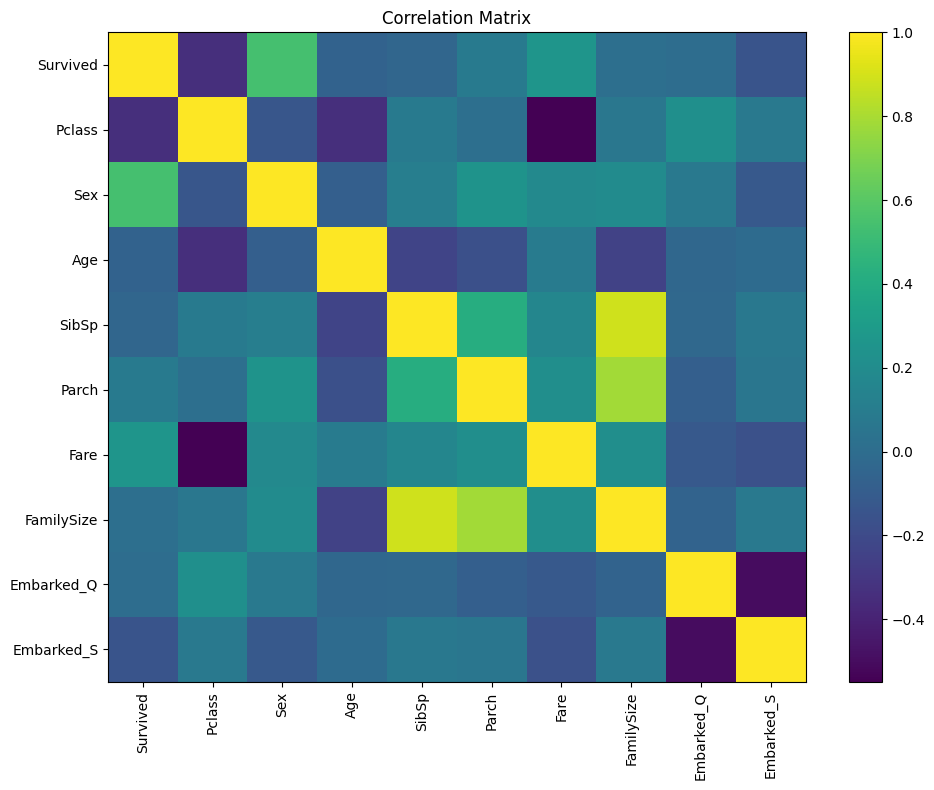

In [27]:
corr = df_encoded.corr(numeric_only=True)
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 11. Key Findings
- The overall survival rate was approximately 38%.
- Female passengers had significantly higher survival rates than male passengers.
- First-class passengers had the highest survival probability, while third-class passengers had the lowest.
- Missing values in Age and Embarked required cleaning before analysis.
- Fare varied strongly by passenger class.
- Correlation analysis showed that Sex and Pclass were strongly associated with survival.

In [28]:
print(f"Overall survival rate: {df['Survived'].mean():.2%}")
print(f"Female survival rate: {df.groupby('Sex')['Survived'].mean()['female']:.2%}")
print(f"Male survival rate: {df.groupby('Sex')['Survived'].mean()['male']:.2%}")
print("\nSurvival rate by passenger class:")
print(df.groupby('Pclass')['Survived'].mean().sort_index().apply(lambda x: f'{x:.2%}'))

Overall survival rate: 38.38%
Female survival rate: 74.20%
Male survival rate: 18.89%

Survival rate by passenger class:
Pclass
1    62.96%
2    47.28%
3    24.24%
Name: Survived, dtype: object


## 12. Conclusion

This EDA project showed that survival on the Titanic was strongly associated with gender and passenger class. The project also demonstrated essential data analysis skills including missing value handling, data cleaning, visualization, feature engineering, and correlation analysis.